In [1]:
import numpy as onp

from jax import config
config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import random, jit, lax, vmap, jacfwd, remat
from jax.example_libraries import optimizers

import time
import os
from jax_md import space, smap, energy, minimize, quantity, simulate, rigid_body

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import EllipseCollection
import seaborn as sns

sns.set_style(style='white')

def format_plot(x, y):
  plt.xlabel(x, fontsize=20)
  plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
  plt.gcf().set_size_inches(
    shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
    shape[1] * 1.5 * plt.gcf().get_size_inches()[1],
  )
  plt.tight_layout()

In [2]:
def get_psi_k(displacement_all, k=6, r0=1.1, alpha=100):

  def weight(r):
    return jnp.where(r<1e-7, 0., 1.0/(1 + jnp.exp(alpha*(r - r0))))

  i_imaginary = complex(0,1)
  def get_ylms(dR_ij):
    epsilon = 0.00001 #avoids nan in derivative
    dR_ij = jnp.where(dR_ij==0.0, epsilon, dR_ij)
    theta = jnp.arctan2(dR_ij[1], dR_ij[0])
    return jnp.exp(i_imaginary*k*theta)

  def calculate_order_param(R):
    v_get_ylms = vmap(vmap(get_ylms))
    ds = displacement_all(R, R)
    r = space.distance(ds)
    w = weight(r)
    psi_k = (jnp.sum(v_get_ylms(ds)*w, axis=0)/(jnp.sum(w, axis=0)+0.00001))
    return psi_k

  def average_order_param(R):
    psi_k = calculate_order_param(R)
    return jnp.abs(jnp.mean(psi_k))

  return average_order_param

In [3]:
def make_2D_lattice_from_index_list(index_list,
                                    a0=jnp.array([jnp.sqrt(2),0.0]),
                                    a1=jnp.array([0.0,jnp.sqrt(2)]),
                                    unitcell=lambda a0, a1: jnp.array([[0.0, 0.0],
                                                                      a0,
                                                                      a1]),
                                    lattice_constant=lambda a0, a1, i, j: jnp.array([[i*a0+j*a1]]),
                                    offset=jnp.array([0.0,0.0])):
  unitcell_particles = unitcell(a0, a1) + offset 
  N = len(unitcell_particles)*index_list.shape[0]
  def get_cell(i,j):
    cell_shift = lattice_constant(a0, a1, i, j)
    return unitcell_particles + cell_shift

  return jnp.reshape(vmap(get_cell, in_axes=(0, 0))(index_list[:,0],index_list[:,1]),(N,2))

def make_2D_lattice(irange, jrange, **kwargs):
  index_list = jnp.array([ [i,j] for i in irange for j in jrange])
  return make_2D_lattice_from_index_list(index_list, **kwargs)

In [4]:
@jit
def thetas_to_shape(thetas, species, radius=0.5, center_mass=1.0, patch_mass=1e-5):
  # Convert angles to patch positions
  patch_positions = jnp.zeros((len(thetas), 2), dtype = jnp.float64)
  patch_positions = patch_positions.at[:,0].set(radius*jnp.cos(thetas))
  patch_positions = patch_positions.at[:,1].set(radius*jnp.sin(thetas))

  # Add the central particle (position (0, 0)) to the list of positions
  central_particle_position = jnp.array([[0.0, 0.0]])
  positions = jnp.concatenate((central_particle_position, patch_positions), axis=0)

  if not len(thetas)+1 == len(species):
    raise ValueError("Must provide species information for every particle")

  # Combine positions and species to form a patchy particle rigid_body object
  masses = jnp.array([center_mass] + len(thetas)*[patch_mass])
  shape = rigid_body.point_union_shape(positions, masses).set(point_species=species)
  return shape

In [5]:
def body_to_plot(body, thetas, species, radius=0.5):
  shape = thetas_to_shape(thetas, species, radius=radius)
  body_pos = vmap(rigid_body.transform, (0, None))(body, shape)
  bodypos = body_pos.reshape(-1, 2)
  species_list = jnp.array(list(species) * len(body.center))

  inds_at_id = lambda id: jnp.squeeze(jnp.argwhere(species_list==id))
  center_particles = bodypos[inds_at_id(0)]
  list_of_patch_particles = []
  for i in range(1, len(species)):
    list_of_patch_particles += [bodypos[inds_at_id(i)]]

  return center_particles, list_of_patch_particles

In [20]:
### Global Parameters
M = 4
A0 = 1.8
A1 = 1.8
UNITCELL_SQ = lambda a0, a1: jnp.array([[0.0,0.0]])
LATTICE_CONSTANT_SQ = lambda a0, a1, i, j: jnp.array([[i*a0+j*a1]])
UNITCELL_SQ = jit(UNITCELL_SQ)
LATTICE_CONSTANT_SQ = jit(LATTICE_CONSTANT_SQ)
N = M**2
DIMENSION = 2

RHO = 0.25
BOX_SIZE = (N/RHO)**(1/2)

kT = 0.2
dt = 1e-3
RADIUS = 0.5
K = 4
R0 = RADIUS*2*1.1
THETAS = jnp.array([0, jnp.pi/2.0, jnp.pi, jnp.pi*3/2.0])
SPECIES = jnp.array([0, 1, 2, 3, 4], dtype = jnp.int32)
NUM_SPECIES = len(set(list(onp.array(SPECIES))))

key=random.PRNGKey(48)

R = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0=jnp.array([A0,0.0]),
                      a1=jnp.array([0.0,A1]),
                      unitcell= UNITCELL_SQ,
                      lattice_constant=LATTICE_CONSTANT_SQ,
                      offset=jnp.array([0.01, 0.03]))

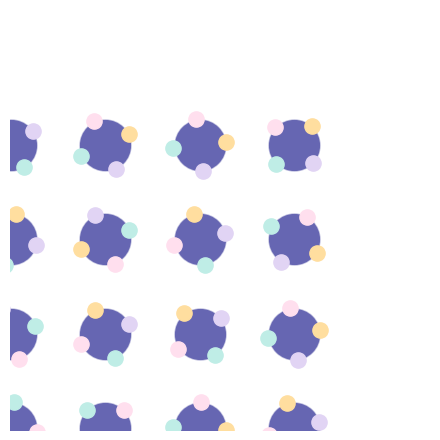

In [21]:
# Conver to rigid body object
patchy_particle_shape = thetas_to_shape(THETAS, SPECIES)

# Choose random orientations for each patchy particle
angle_key, split = random.split(key)
orientations = random.uniform(angle_key, (len(R),), dtype=jnp.float64) * jnp.pi * 2

# Combine orientations with square lattice positions
full_configuration = rigid_body.RigidBody(R, orientations)

fig, ax = plt.subplots()
fig.set_size_inches(3, 3)
center_pos, patches_pos = body_to_plot(full_configuration, THETAS, SPECIES)
patches_color = ['#e1d4f4', '#ffde9f', '#ffdfee', '#bfede6', '#f6fca6']
ax.add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                       facecolors='navy', alpha = 0.6, 
                                       offsets=list(center_pos), transOffset=ax.transData))
for i in range(1, NUM_SPECIES):
  ax.add_collection(EllipseCollection(widths=0.29, heights=0.29, angles=0, units='xy',
                                      facecolors=patches_color[i-1], edgecolors=patches_color[i-1], alpha = 1.0, 
                                      offsets=list(patches_pos[i-1]), transOffset=ax.transData))
plt.xlim([0, BOX_SIZE])
plt.ylim([0, BOX_SIZE])
plt.axis('off')
finalize_plot((1, 1))

In [22]:
displacement, shift = space.periodic(BOX_SIZE)
key, split = random.split(key)

soft_eps = jnp.zeros((NUM_SPECIES, NUM_SPECIES))
soft_eps = soft_eps.at[0, 0].set(10000.0)
morse_eps = jnp.zeros((NUM_SPECIES, NUM_SPECIES))
morse_eps = morse_eps.at[1, 3].set(4.0)
morse_eps = morse_eps.at[3, 1].set(4.0)
morse_eps = morse_eps.at[2, 4].set(4.0)
morse_eps = morse_eps.at[4, 2].set(4.0)
energy_fn_soft = energy.soft_sphere_pair(displacement, species = NUM_SPECIES, sigma = RADIUS*2, epsilon = soft_eps, alpha = 4.0)
energy_fn_morse = energy.morse_pair(displacement, species = NUM_SPECIES, sigma = 0.0, epsilon = morse_eps, alpha = 9.0, r_cutoff = 1.5)
energy_fn_all = lambda R, **kwargs: energy_fn_soft(R, **kwargs) + energy_fn_morse(R, **kwargs)
energy_fn = rigid_body.point_energy(energy_fn_all, patchy_particle_shape)
energy_fn = jit(energy_fn)

init, apply = simulate.nvt_nose_hoover(energy_fn, shift, dt, kT = kT)
step = jit(lambda i, state: apply(state))
state = init(key, full_configuration, mass=patchy_particle_shape.mass())

In [23]:
displacement_all = vmap(vmap(displacement, (0, None), 0), (None, 0), 0)
order_param = get_psi_k(displacement_all, k=4, r0=R0, alpha=100)

PE = [energy_fn(state.position)]
KE = [rigid_body.kinetic_energy(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
T = [rigid_body.temperature(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
loss = [order_param(state.position.center)]
trajectory = [state.position]

N_steps = 400
inner_steps = 100
print_every = 100
old_time = time.time()
print('Step\tKE\tPE\tTotal Energy\ttime/step')
print('----------------------------------------')

for i in range(N_steps):
  state = lax.fori_loop(0, inner_steps, step, state)

  PE += [energy_fn(state.position)]
  KE += [rigid_body.kinetic_energy(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
  T += [rigid_body.temperature(position=state.position, momentum=state.momentum, mass=patchy_particle_shape.mass())]
  loss += [order_param(state.position.center)]
  trajectory += [state.position]

  if i % print_every == 0 and i > 0:
    new_time = time.time()
    print(
      '{}\t{:.2f}\t{:.2f}\t{:.3f}\t{:.3f}'.format(
        i * inner_steps,
        KE[-1],
        PE[-1],
        KE[-1] + PE[-1],
        (new_time - old_time) / print_every / inner_steps,
      )
    )
    old_time = new_time

PE = jnp.array(PE)
KE = jnp.array(KE)
T = jnp.array(T)
loss = jnp.array(loss)

Step	KE	PE	Total Energy	time/step
----------------------------------------
10000	3.97	-29.04	-25.067	0.002
20000	4.16	-41.83	-37.661	0.001
30000	4.74	-50.38	-45.636	0.001


<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4257/1828304066.py:17: SyntaxWarning: invalid escape sequence '\p'
  axs[2].set_ylabel('$\psi_4$', fontsize = 18)


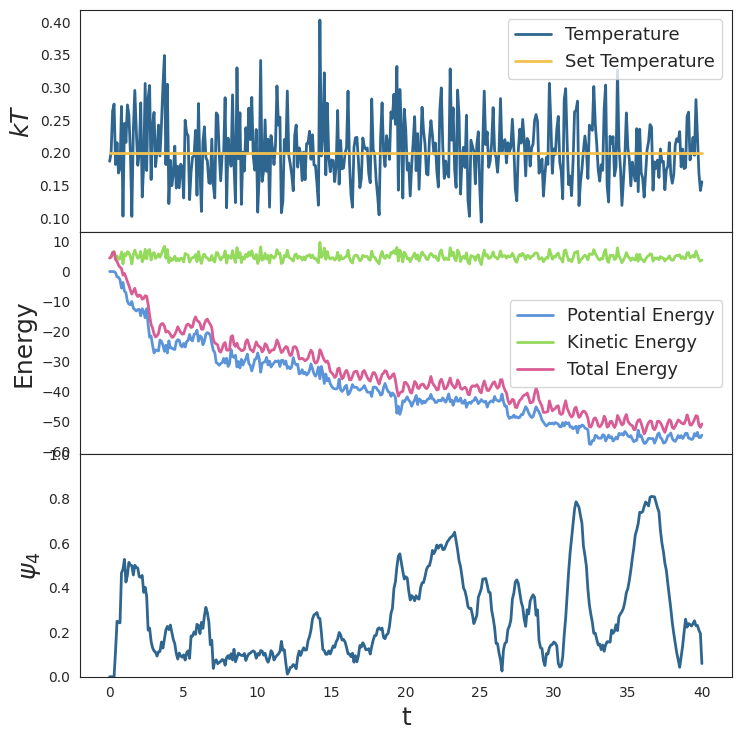

In [24]:
t = onp.arange(0, N_steps+1) * dt * inner_steps

fig = plt.figure(figsize = (8, 5))
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True)

axs[0].plot(t, T, label = 'Temperature', color = '#2f6690', linewidth = 2)
axs[0].plot(t, onp.ones(len(t))*0.2, color = '#f2c14e', label = 'Set Temperature', linewidth = 2)
axs[0].legend(fontsize = 13)
axs[0].set_ylabel('$kT$', fontsize = 18)
axs[1].plot(t, PE, label='Potential Energy', color = '#5c94da', linewidth = 2)
axs[1].plot(t, KE, label='Kinetic Energy', color = '#94da5c', linewidth = 2)
axs[1].plot(t, PE + KE, label='Total Energy', color = '#da5c94', linewidth = 2)
axs[1].legend(fontsize = 13)
axs[1].set_ylabel('Energy', fontsize = 18)
axs[2].plot(t, loss, color = '#2f6690', linewidth = 2)
axs[2].set_ylabel('$\psi_4$', fontsize = 18)
axs[2].set_ylim(0.0, 1.0)
axs[2].set_xlabel('t', fontsize = 18)
finalize_plot()

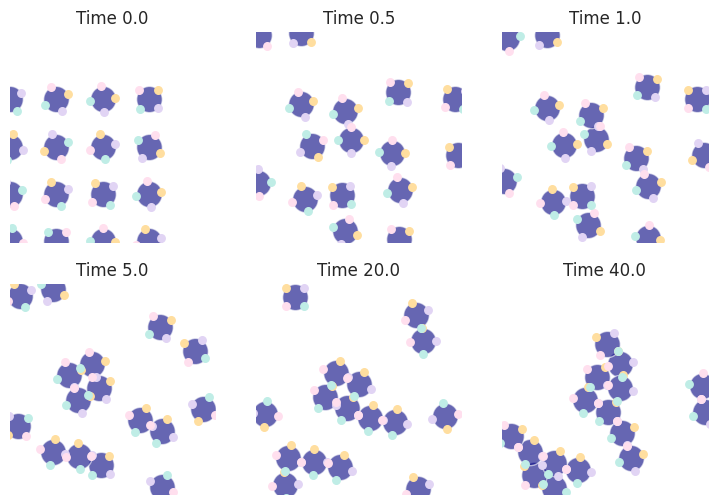

In [25]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(9, 6)
index = [0, 5, 10, 50, 200, 400]#, 1000]
patches_color = ['#e1d4f4', '#ffde9f', '#ffdfee', '#bfede6', '#f6fca6']
for i in range(2):
  for j in range(3):
    center_pos, patches_pos = body_to_plot(trajectory[index[i*3+j]], THETAS, SPECIES)

    axs[i, j].add_collection(EllipseCollection(widths=1.0, heights=1.0, angles=0, units='xy',
                                           facecolors='navy', alpha = 0.6, 
                                           offsets=list(center_pos), transOffset=axs[i, j].transData))
    for k in range(1, NUM_SPECIES):
      axs[i, j].add_collection(EllipseCollection(widths=0.29, heights=0.29, angles=0, units='xy',
                                      facecolors=patches_color[k-1], edgecolors=patches_color[k-1], alpha = 1.0, 
                                      offsets=list(patches_pos[k-1]), transOffset=axs[i, j].transData))

    axs[i, j].set_xlim([0, BOX_SIZE])
    axs[i, j].set_ylim([0, BOX_SIZE])
    axs[i, j].set_axis_off()
    axs[i, j].set_title("Time "+str(index[i*3+j]*dt*inner_steps))

In [ ]:
@jit
def energy_matrix(eng):
  i, j =jnp.triu_indices(NUM_PATCHES)
  eng_m = jnp.zeros((NUM_PATCHES, NUM_PATCHES))
  eng_m = eng_m.at[i, j].set(eng)
  return eng_m.at[j, i].set(eng)

@jit
def run_sim(thetas_and_energies, initial_positions, num_steps, key, kT):

  displacement, shift = space.periodic(BOX_SIZE)
  key, split = random.split(key)

  # Setup Rigid Bodies
  thetas = thetas_and_energies[:NUM_PATCHES]
  patchy_particle_shape = thetas_to_shape(thetas, SPECIES)
  angle_key, split = random.split(key)
  orientations = random.uniform(angle_key, (len(R),), dtype=jnp.float64) * jnp.pi * 2
  full_configuration = rigid_body.RigidBody(R, orientations)

  # Setup Interactions
  soft_eps = jnp.zeros((NUM_SPECIES, NUM_SPECIES))
  soft_eps = soft_eps.at[0, 0].set(10000.0)
  morse_eps = energy_matrix(thetas_and_energies[NUM_PATCHES:])

  energy_fn_soft = energy.soft_sphere_pair(displacement, species = NUM_SPECIES, sigma = RADIUS*2, epsilon = soft_eps, alpha = 4.0)
  energy_fn_morse = energy.morse_pair(displacement, species = NUM_SPECIES, sigma = 0.0, epsilon = morse_eps, alpha = 9.0, r_cutoff = 1.5)
  energy_fn_all = lambda R, **kwargs: energy_fn_soft(R, **kwargs) + energy_fn_morse(R, **kwargs)
  energy_fn = rigid_body.point_energy(energy_fn_all, patchy_particle_shape)
  energy_fn = jit(energy_fn)

  # Setup Integrator
  init, apply = simulate.nvt_nose_hoover(energy_fn, shift, dt, kT = kT)
  step = jit(lambda i, state: apply(state))
  state = init(key, full_configuration, mass=patchy_particle_shape.mass())

  do_step = lambda state, t: (step(state), 0.)
  do_step = jit(do_step)
  inner_steps = jnp.arange(INNER_STEPS)

  @remat
  def do_outer_step(state, i):
    state, _ = lax.scan(do_step, state, inner_steps)
    return state, 0.

  do_outer_step = jit(do_outer_step)

  steps = jnp.arange(int(num_steps/INNER_STEPS))
  state, losses = lax.scan(do_outer_step, state, steps)

  return state

run_sim = jit(run_sim, static_argnums = 2)
v_run_sim = jit(vmap(run_sim, in_axes = (None, None, None, 0, None)), static_argnums = 2)
many_states_run_sim = jit(vmap(run_sim, in_axes=(None, 0, None, 0, None)), static_argnums = 2)

In [ ]:
@jit
def loss_fn(R, k=6, r0=1.1, alpha=100):
  displacement, shift = space.periodic(BOX_SIZE)
  displacement_all = vmap(vmap(displacement, (0, None), 0), (None, 0), 0)
  order_param = get_psi_k(displacement_all, k = k, r0 = TARGET, alpha = ALPHA)
  return (1-order_param(R))**2

v_loss = vmap(loss_fn, in_axes = (0))
v_loss = jit(v_loss)
avg_loss = lambda R_batched: jnp.mean(v_loss(R_batched))
avg_loss = jit(avg_loss)

In [ ]:
def run_partial_sim(params, key, batch_size):
  R = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                        a0=jnp.array([A0,0.0]),
                        a1=jnp.array([0.0,A1]),
                        unitcell= UNITCELL_SQ,
                        lattice_constant=LATTICE_CONSTANT_SQ,
                        offset=jnp.array([0.01, 0.03]))
  sim_keys = random.split(key, batch_size)
  states = v_run_sim(params, R, NUM_STEPS_TO_RUN, sim_keys, kT)
  return states.position

def get_mean_loss(params, initial_positions, keys):
  # pdb.set_trace()
  states = many_states_run_sim(params, initial_positions, NUM_STEPS_TO_OPT, keys, kT)
  return avg_loss(states.position, k=K, r0=RO, alpha=ALPHA)

g_mean_loss = jit(value_and_grad(get_mean_loss))

In [ ]:
def optimize(input_params, key, opt_steps, batch_size, save_every, filename, learning_rate=0.01):

  learning_rate_schedule = jnp.ones(opt_steps)*learning_rate
  ind = int(opt_steps / 3)
  learning_rate_schedule = learning_rate_schedule.at[ind:2*ind].set(learning_rate * 0.5)
  learning_rate_schedule = learning_rate_schedule.at[2*ind:].set(learning_rate * 0.1)
  learning_rate_fn = lambda i: learning_rate_schedule[i]

  opt_init, opt_update, get_params = optimizers.adam(step_size=learning_rate_fn)
  # loss_file = filename + 'loss.txt'
  # param_file = filename + 'params.txt'
  # grad_file = filename + 'grad.txt'

  def clip_gradient(g, clip=10000.0):
    return jnp.array(jnp.where(jnp.abs(g) > clip, jnp.sign(g)*clip, g))

  def step(i, opt_state, key, batch_size=10, save_every=10):

    params = get_params(opt_state)
    key, split = random.split(key)
    simulation_keys = random.split(split, batch_size)
    initial_positions = run_partial_sim(params, key, batch_size)
      
    loss, gs = g_mean_loss(params, initial_positions, simulation_keys)
    gs = clip_gradient(gs)
    g = gs
    # gs = vmap(clip_gradient)(gs)

    # if BATCH_SIZE > 1:
    #   g = jnp.mean(jnp.array(gs), axis = 0)
    # else:
    #   g = gs

    if(i%save_every==0):

      # if(i==save_every):
      #   cmd = "w"
      # else:
      #   cmd = "a"

      # with open(loss_file, cmd) as outfile1:
      #   outlist1 = onp.array(loss).tolist()
      #   outfile1.write("{}".format(loss)+'\n')

      # with open(param_file, cmd) as outfile2:
      #   outlist2 = onp.array(params).tolist()
      #   separator=', '
      #   outfile2.write(separator.join(['{}'.format(temp) for temp in outlist2])+'\n')

      # with open(grad_file, cmd) as outfile3:
      #   outlist3 = onp.array(g).tolist()
      #   separator=', '
      #   outfile3.write(separator.join(['{}'.format(temp) for temp in outlist3])+'\n')

      print("Loss: {}".format(loss))
      print("Parameters: {}".format(params))
      print("Gradient: {}".format(g))

    return opt_update(i, g, opt_state), loss, g

  opt_state = opt_init(input_params)
  iteration = 0
  i0 = iteration
  min_loss_params = input_params
  min_loss = 1e6
  losses = []
  gradients = []
  opt_params = []
  for _ in range(i0,i0 + opt_steps):
    iteration += 1
    key, split = random.split(key)
    new_opt_state, loss, g = step(iteration, opt_state, split, batch_size=batch_size, save_every=save_every)
    if loss < min_loss:
      min_loss = loss
      min_loss_params = get_params(opt_state)
    opt_state = new_opt_state
    losses.append(min_loss)
    gradients.append(g)
    opt_params.append(get_params(opt_state))

  return min_loss, min_loss_params, losses, gradients, opt_params

In [ ]:
min_loss, min_loss_params, losses, gradients, opt_params = optimize(thetas_and_energies, key, OPT_STEPS, BATCH_SIZE, SAVE_EVERY, '', learning_rate = 0.1)
print('Min loss: ', min_loss)
print('Min loss params: ', min_loss_params)
onp.save("losses.npy", losses)
onp.save("gradients.npy", gradients)
onp.save("params.npy", opt_params)